In [1]:
import zipfile as zf

In [2]:
zipRef = zf.ZipFile('archive.zip')

In [3]:
zipRef.extractall('dataset')

In [4]:
zipRef.close()

In [5]:
trainDir = 'dataset/training_set/training_set'
testDir = 'dataset/test_set/test_set'

In [6]:
import os
for dirPath, dirNames, fileNames in os.walk('dataset'):
  print(f'there are {len(dirNames)} directories and {len(fileNames)} files in {dirPath}')
  for filename in fileNames:
    if not filename.lower().endswith(".jpg"):
      file_path = os.path.join(dirPath, filename)
      os.remove(file_path)

there are 2 directories and 0 files in dataset
there are 1 directories and 0 files in dataset/training_set
there are 2 directories and 0 files in dataset/training_set/training_set
there are 0 directories and 4001 files in dataset/training_set/training_set/cats
there are 0 directories and 4006 files in dataset/training_set/training_set/dogs
there are 1 directories and 0 files in dataset/test_set
there are 2 directories and 0 files in dataset/test_set/test_set
there are 0 directories and 1012 files in dataset/test_set/test_set/cats
there are 0 directories and 1013 files in dataset/test_set/test_set/dogs


In [7]:
import pathlib
import numpy as np
data_dir = pathlib.Path('dataset/training_set/training_set')
classNames = np.array(sorted([item.name for item in data_dir.glob('*')]))

In [8]:
classNames

array(['cats', 'dogs'], dtype='<U4')

In [9]:
import matplotlib.pyplot as plt
import matplotlib.image as matimg
import random

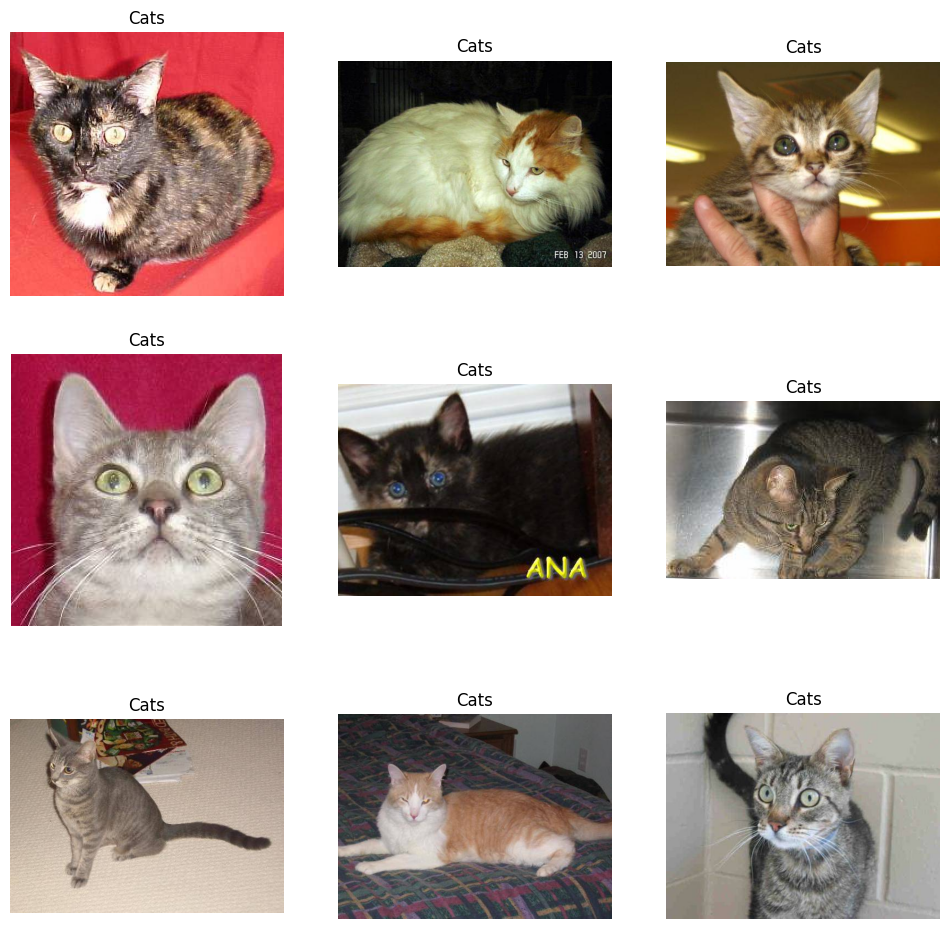

In [10]:
catsImgs = os.listdir('dataset/training_set/training_set/cats')
plt.figure(figsize=(12,12))
for i in range(9):
  randomImg = random.choice(catsImgs)
  imgArray = matimg.imread(f'dataset/training_set/training_set/cats/{randomImg}')
  plt.subplot(3,3, i+1)
  plt.imshow(imgArray)
  plt.title("Cats")
  plt.axis(False)

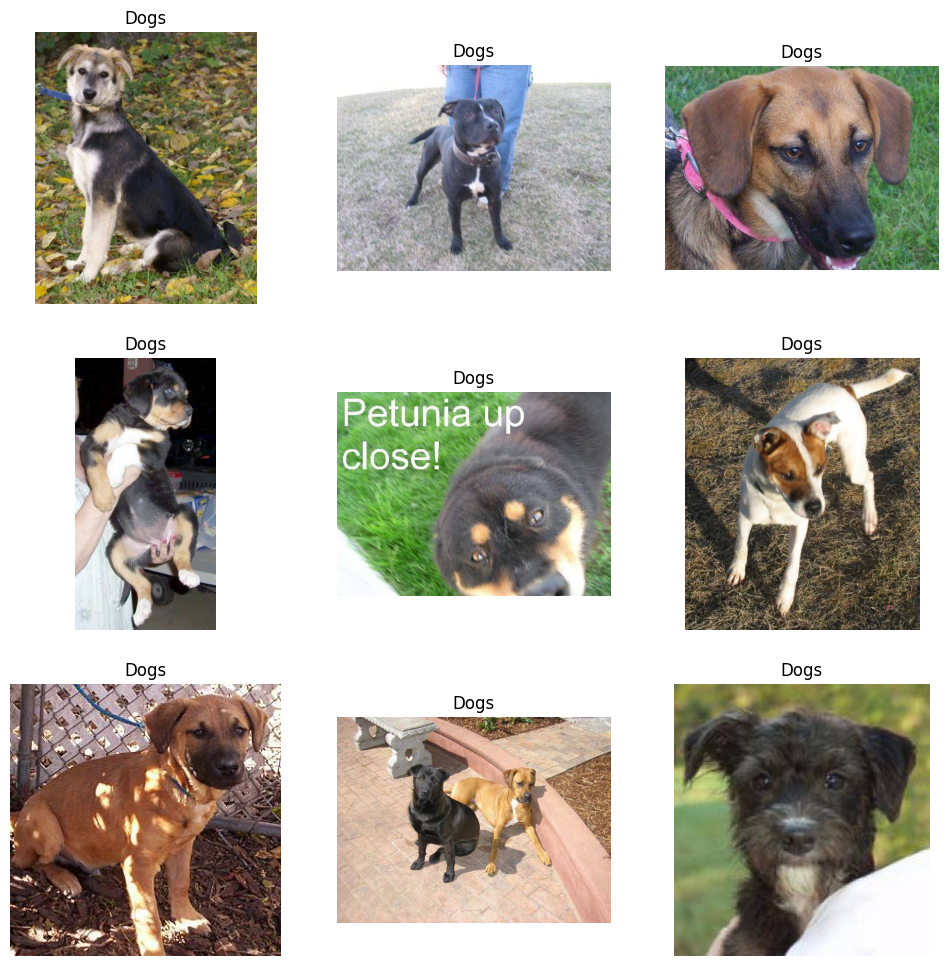

In [11]:
dogsImgs = os.listdir('dataset/training_set/training_set/dogs')
plt.figure(figsize=(12,12))
for i in range(9):
  randomImg = random.choice(dogsImgs)
  imgArray = matimg.imread(f'dataset/training_set/training_set/dogs/{randomImg}')
  plt.subplot(3,3, i+1)
  plt.imshow(imgArray)
  plt.title("Dogs")
  plt.axis(False)

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [13]:
trainDataAugmented = ImageDataGenerator(rescale= 1/255,
                                        rotation_range= 0.2,
                                        zoom_range=0.2,
                                        horizontal_flip=True,
                                        width_shift_range=0.2,
                                        height_shift_range=0.2)
testDataAugmented = ImageDataGenerator(rescale= 1/255)

In [14]:
trainDataAugmentedShuffled = trainDataAugmented.flow_from_directory(trainDir,
                                                                    target_size = (224,224),
                                                                    shuffle=True,
                                                                    class_mode="binary",
                                                                    batch_size=64
                                                                    )

Found 8005 images belonging to 2 classes.


In [15]:
testDataAugmentedShuffled = testDataAugmented.flow_from_directory(testDir,
                                                                    target_size = (224,224),
                                                                    class_mode="binary",
                                                                    batch_size=64
                                                                    )

Found 2023 images belonging to 2 classes.


In [16]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.layers import Dense, Lambda
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping

In [17]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)

In [18]:
url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"

In [19]:
computerVisionCatVSDogs = Sequential([
    Lambda(lambda x: hub.KerasLayer(url, trainable = False)(x), input_shape = (224,224,3)),
    Dense(1,'sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
computerVisionCatVSDogs.compile(
    loss= "binary_crossentropy",
    optimizer = Adam(),
    metrics=["accuracy"]
)

In [21]:
history = computerVisionCatVSDogs.fit(
    trainDataAugmentedShuffled,
    epochs = 100,
    validation_data = testDataAugmentedShuffled,
    validation_batch_size = len(testDataAugmentedShuffled),
    callbacks = [early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 150s 1000ms/step - accuracy: 0.8797 - loss: 0.2782 - val_accuracy: 0.9743 - val_loss: 0.0735
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 101s 803ms/step - accuracy: 0.9770 - loss: 0.0696 - val_accuracy: 0.9832 - val_loss: 0.0584
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 101s 802ms/step - accuracy: 0.9781 - loss: 0.0603 - val_accuracy: 0.9847 - val_loss: 0.0511
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 101s 801ms/step - accuracy: 0.9792 - loss: 0.0530 - val_accuracy: 0.9832 - val_loss: 0.0503
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 101s 805ms/step - accuracy: 0.9792 - loss: 0.0537 - val_accuracy: 0.9852 - val_loss: 0.0485
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 100s 798ms/step - accuracy: 0.9815 - loss: 0.0472 - val_accuracy: 0.9862 - val_loss: 0.0487
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 100s 793ms/step - accuracy: 0.9813 - loss: 0.0458 - val_accuracy: 0.9857 - val_loss: 0.0482
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 100s 794ms/step - accuracy:

In [22]:
print('Accuracy:', history.history['accuracy'][-1])
print('Loss:', history.history['loss'][-1])

Accuracy: 0.9851343035697937
Loss: 0.03777787461876869


In [23]:
computerVisionCatVSDogs.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 1001)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,002 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,008 (11.75 KB)

 Trainable params: 1,002 (3.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,006 (7.84 KB)

In [24]:
def load_and_prep_image(filename, img_shape=224):

    img = tf.io.read_file(filename)
    img = tf.image.decode_image(img)
    img = tf.image.resize(img, size=[img_shape, img_shape])
    img = img/255.
    return img

In [25]:
def pred_and_plot(model, filename, class_names=classNames):

    img = load_and_prep_image(filename)

    pred = computerVisionCatVSDogs.predict(tf.expand_dims(img, axis=0))

    pred_class = class_names[int(tf.round(pred))]

    catOrDog = ''
    if pred_class == 'cats':
      catOrDog = 'A Cat'
    else:
      catOrDog = 'A Dog'

    plt.imshow(img)
    plt.title(f"Prediction: {catOrDog}")
    plt.axis(False);

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


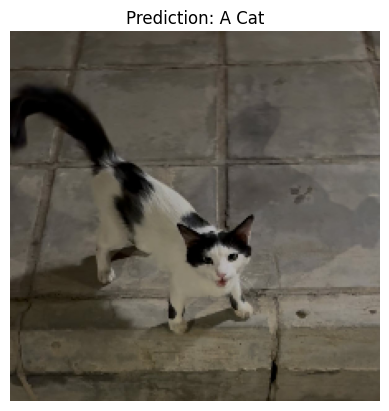

In [26]:
pred_and_plot(computerVisionCatVSDogs, filename='bagira.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


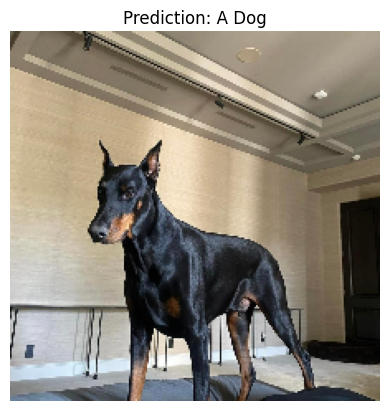

In [27]:
pred_and_plot(computerVisionCatVSDogs, filename='Caesar .jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


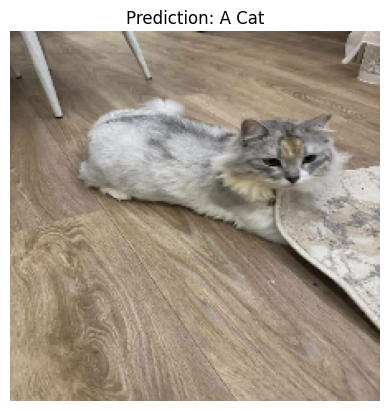

In [28]:
pred_and_plot(computerVisionCatVSDogs, filename='maloha.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


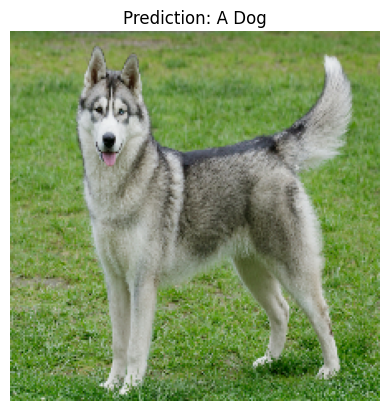

In [29]:
pred_and_plot(computerVisionCatVSDogs, filename='husky-dog.jpg')

In [37]:
computerVisionCatVSDogs.save('my_CatsVsDogs_model.keras')